# Predicting House Prices in California with `LinearRegression()`

In this lab you will start inspect, analyze, visualize house price data from different districts in California, US. After having performed analysis, EDA and some feature engineering, you will build your own `LinearRegression()`  with `SkLearn`. 

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('housing.csv')

# Part 1 - Inspection and Cleaning


#### Import and Inspect your data

Read the `housing.csv` file and make use of some methods to understand your data better. Below is an explanation of the features you are going to work with:

1. **longitude:**  geographical coordinate, east to west position of district
2. **latitude:**  geographical coordinate, north to south position of district
3. **housing_median_age:** the median age of houses in district
4. **total_rooms** Sum of all rooms in district
5. **total_bedrooms** Sum of all bedrooms in district
6. **population:** total population in district
7. **households:** total households in district
8. **median_income:** median household income in district 
9. **median_house_value:** median house value in district
10. **ocean_proximity:** District´s proximity to the ocean

In [48]:
df.head()  



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [50]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### Histograms
Make histograms of all your numeric columns in order to get a good understanding of the distribution of your data points. What do you see?

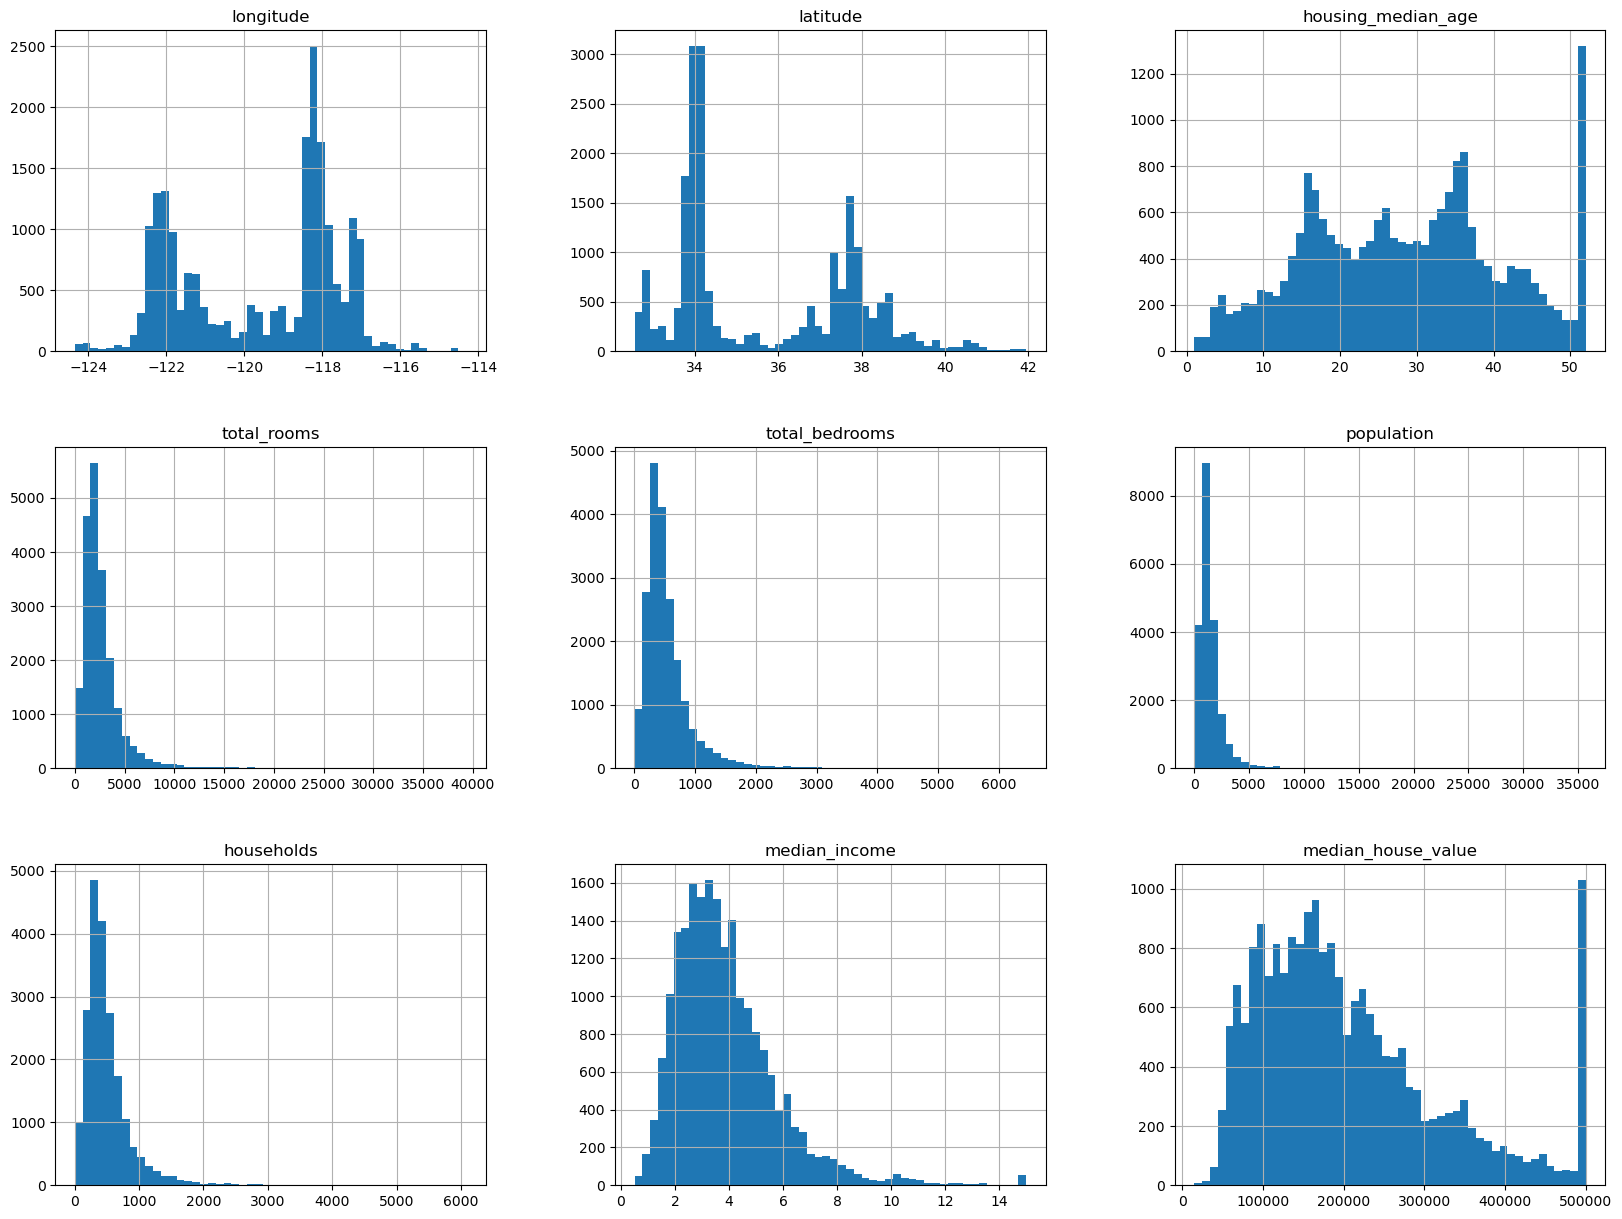

In [51]:
df.hist(bins=50, figsize=(20,15))
plt.show()

#### Let's create some features a tidy up our data

1. Locate your NaN values and make a decision on how to handle them. Drop, fill with mean, or something else, it is entirely up to you. 

In [52]:
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)
print(df['total_bedrooms'].isnull().sum())

0


2. Create three new columns by using simple arithmetic operations. Create one column with "rooms per household", one with "population per household",  and one with "bedrooms per room".

In [53]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['population_per_household'] = df['population'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,2.555556,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,2.109842,0.155797
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,2.802260,0.129516
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,2.547945,0.184458
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,2.181467,0.172096


3. If you check the largest and smallest values of your "rooms per houshold column" you will see two outliers and two values that are just wrong. Drop the four values by index.

In [54]:
df['rooms_per_household'].sort_values(ascending=False).head()

1914     141.909091
1979     132.533333
12447     62.422222
1913      61.812500
11862     59.875000
Name: rooms_per_household, dtype: float64

In [55]:
df['rooms_per_household'].sort_values().head()

5916     0.846154
8219     0.888889
3126     1.000000
14818    1.130435
17820    1.130435
Name: rooms_per_household, dtype: float64

In [56]:
df = df.drop([1914, 1979, 5916, 8219])
df['rooms_per_household'].sort_values(ascending=False).head()

12447    62.422222
1913     61.812500
11862    59.875000
1912     56.269231
9676     52.848214
Name: rooms_per_household, dtype: float64

In [57]:
df['rooms_per_household'].sort_values().head()

3126     1.000000
17820    1.130435
14818    1.130435
4552     1.260870
4550     1.378486
Name: rooms_per_household, dtype: float64

# Part 2 - Exploratory Data Analysis



#### Let's find out what factors have an influence on our predicting variable

1. Let's check out the distribution of our "median house value". Visualize your results with 100 bins.

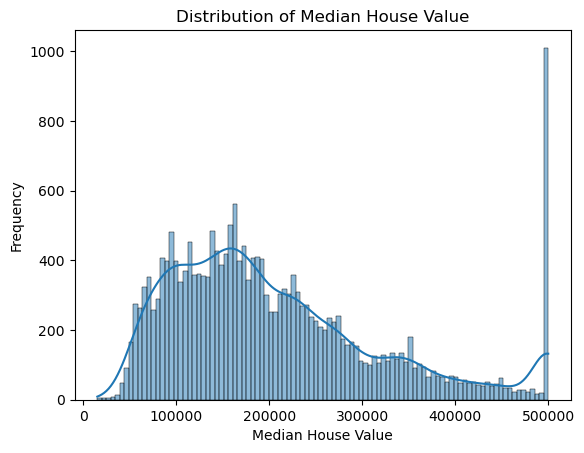

In [58]:
sns.histplot(df['median_house_value'], bins=100, kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

2. Check out what variables correlates the most with "median house value"

In [59]:
correlations = df.corr(numeric_only=True)['median_house_value'].sort_values(ascending=False)
print(correlations)

median_house_value          1.000000
median_income               0.688369
rooms_per_household         0.171586
total_rooms                 0.134173
housing_median_age          0.105653
households                  0.065927
total_bedrooms              0.049471
population_per_household   -0.023743
population                 -0.024598
longitude                  -0.045911
latitude                   -0.144413
bedrooms_per_room          -0.233824
Name: median_house_value, dtype: float64


3. Let's check out the distribution of the column that has the highest correlation to "median house value". Visualize your results with 100 bins.

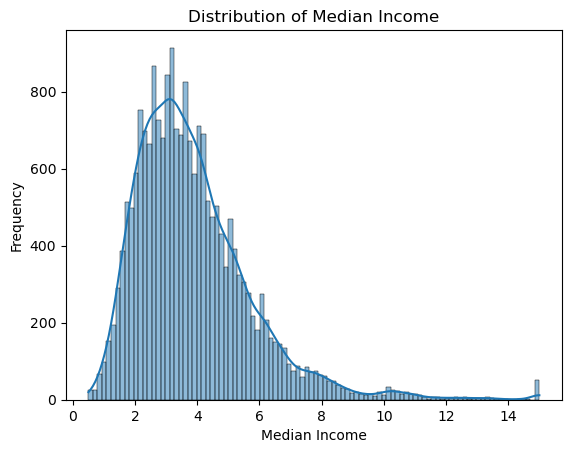

In [60]:
sns.histplot(df['median_income'], bins=100, kde=True)
plt.title('Distribution of Median Income')
plt.xlabel('Median Income')
plt.ylabel('Frequency')
plt.show()

4. Visualize the "median house value" and "median income" in a jointplot (kind="reg"). What do you see?

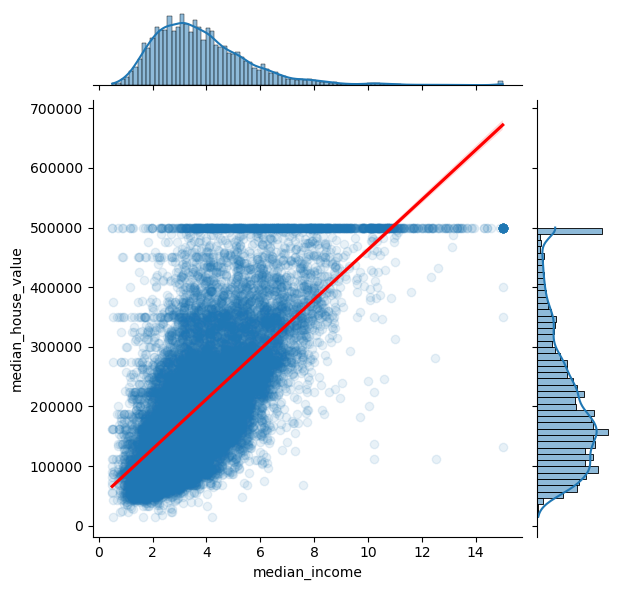

In [61]:
sns.jointplot(x='median_income', y='median_house_value', data=df, kind='reg', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.show()

5. Make the same visualization as in the above, but, cahnge the kind parameter to "kde". What extra information does this type of visualization convey, that the one in the above does not?

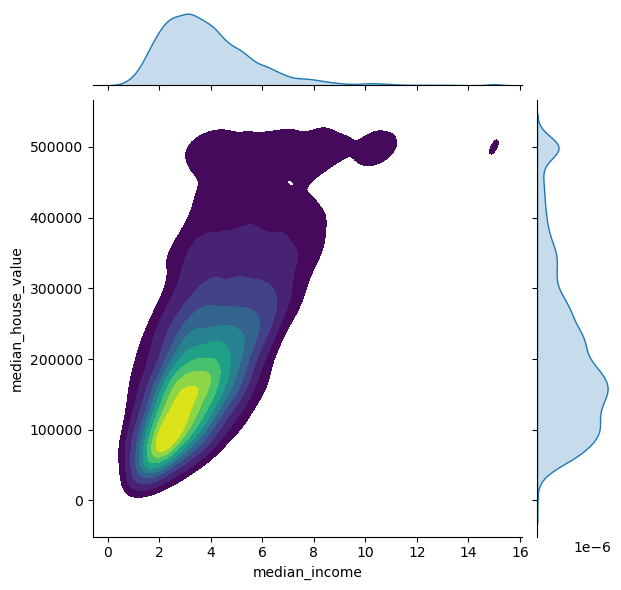

In [62]:
sns.jointplot(x='median_income', y='median_house_value', data=df, kind='kde', fill=True,cmap='viridis')
plt.show()

#### Let's get schwifty with some EDA

1. Create a new categorical column from the "median income" with the following quartiles `[0, 0.25, 0.5, 0.75, 0.95, 1]` and label them like this `["Low", "Below_Average", "Above_Average", "High", "Very High"]` and name the column "income_cat"

In [63]:
df['income_cat'] = pd.qcut(df['median_income'], q=[0, 0.25, 0.5, 0.75, 0.95,1], labels=["Low", "Below Average", "Above Average", "High", "Very High"])
print(df['income_cat'].value_counts())
print(df[['median_income', 'income_cat']].head())

income_cat
Above Average    5160
Low              5159
Below Average    5159
High             4126
Very High        1032
Name: count, dtype: int64
   median_income     income_cat
0         8.3252      Very High
1         8.3014      Very High
2         7.2574           High
3         5.6431           High
4         3.8462  Above Average


2. Using the Seaborn library, plot the count of your new column and set the `hue` to "ocean_proximity". What interesting things can you see?

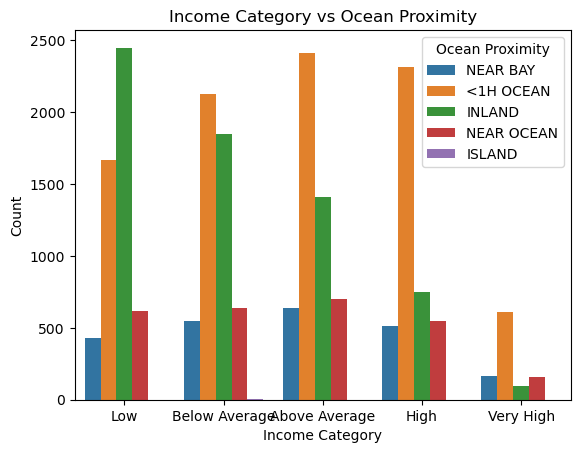

In [64]:
sns.countplot(x='income_cat', hue='ocean_proximity', data=df)
plt.title('Income Category vs Ocean Proximity')
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.legend(title='Ocean Proximity', loc='upper right')
plt.show()

3. Create two barplots where you set "y="median_house_value" on both, and the x is first "income cat" and then "ocean_proximity". How does these two graphs complement what you saw in the graph in your previous question?

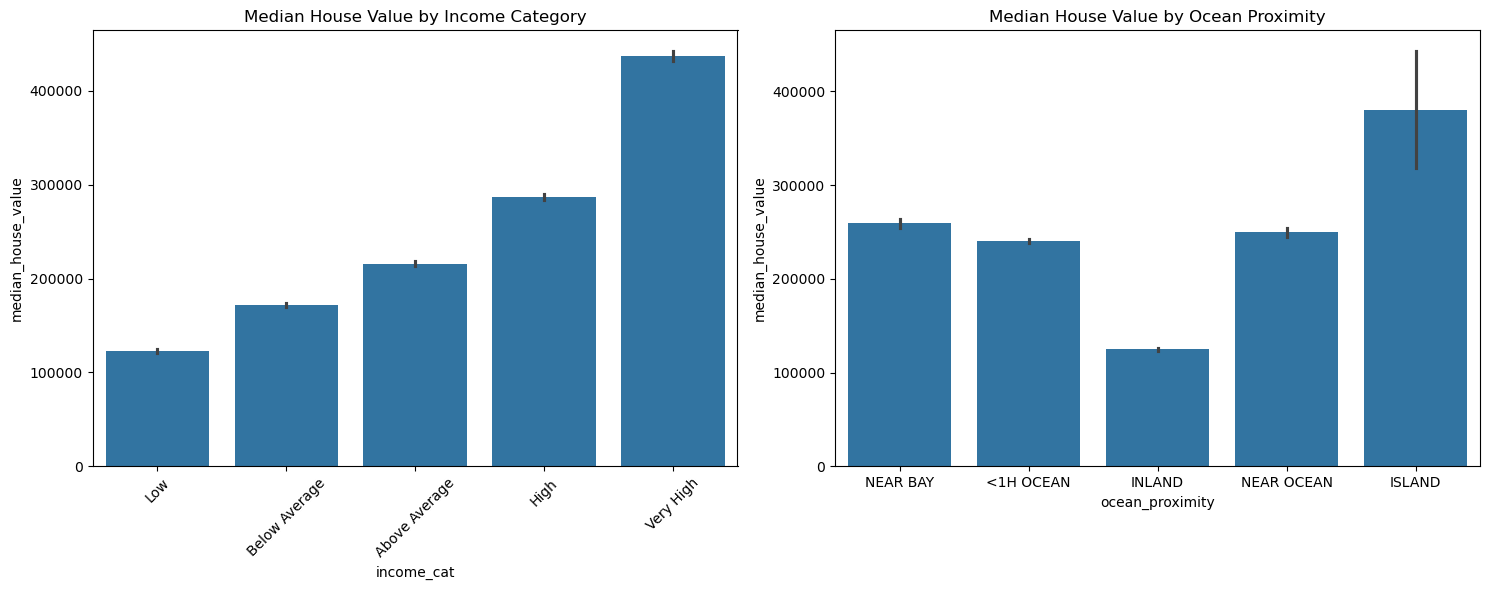

In [67]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))



sns.barplot(x='income_cat', y='median_house_value', data=df,ax=axes[0])
axes[0].set_title('Median House Value by Income Category')
axes[0].tick_params(axis='x', rotation=45)
sns.barplot(x='ocean_proximity', y='median_house_value', data=df, ax=axes[1])
axes[1].set_title('Median House Value by Ocean Proximity')
plt.tight_layout()
plt.show()

4. Create a pivoted dataframe where you have the values of the "income cat" column as indices and the values of the "ocean_proximity" column as columns. Also drop the "ISLAND" column that you'll get.

In [68]:
pivot_df = pd.crosstab(df['income_cat'], df['ocean_proximity'])
pivot_df = pivot_df.drop("ISLAND", axis=1)
print(pivot_df)

ocean_proximity  <1H OCEAN  INLAND  NEAR BAY  NEAR OCEAN
income_cat                                              
Low                   1669    2449       426         614
Below Average         2124    1847       548         636
Above Average         2412    1409       638         701
High                  2318     748       513         547
Very High              612      96       165         159


5. Turn your pivoted dataframe into a heatmap. The heatmap should have annotations in integer format.

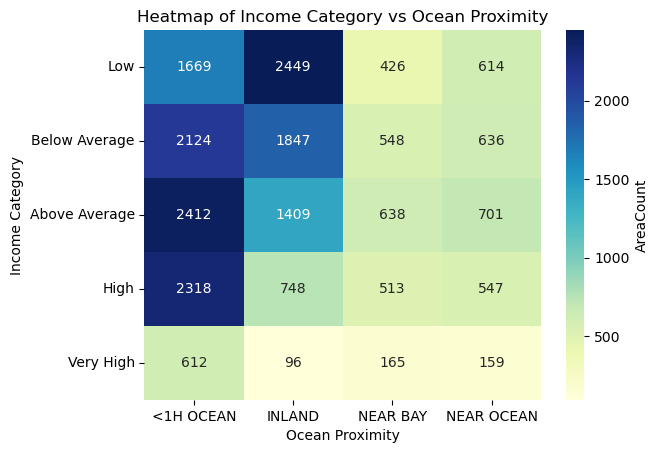

In [69]:
sns.heatmap(pivot_df, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'AreaCount'})
plt.title('Heatmap of Income Category vs Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Income Category')
plt.show()

# Part 3 - Preparing your Data



#### Splitting, Preparing and Engineering some Features

1. Let's drop the "income_cat" column as it has served its purpose already. We don't need for our model as we already have "median income".
Not dropping "incom cat" will lead to multicolinearity.

In [71]:
df.drop('income_cat', axis=1, inplace=True)
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'rooms_per_household',
       'population_per_household', 'bedrooms_per_room'],
      dtype='object')


2. Select your floating point columns and standardize your data by calculating the Z-score. You can apply the `stats.zscore()` method in a lambda function. Save your results to a variable called `z_scored`. 

In [72]:
import scipy.stats as stats

In [73]:
float_cols = df.select_dtypes(include=['float64']).columns
z_scores = df[float_cols].apply(lambda x: stats.zscore(x))
print(z_scores.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.327701  1.052665            0.982224    -0.804958       -0.972617   
1  -1.322710  1.043301           -0.606873     2.045696        1.356973   
2  -1.332692  1.038619            1.856227    -0.535890       -0.827167   
3  -1.337683  1.038619            1.856227    -0.624357       -0.719867   
4  -1.337683  1.038619            1.856227    -0.462549       -0.612568   

   population  households  median_income  median_house_value  \
0   -0.974710   -0.977332       2.344595            2.129854   
1    0.861243    1.669812       2.332068            1.314311   
2   -0.821052   -0.843928       1.782561            1.258844   
3   -0.766300   -0.734067       0.932876            1.165243   
4   -0.760118   -0.629436      -0.012919            1.173043   

   rooms_per_household  population_per_household  bedrooms_per_room  
0             0.744324                 -0.049604          -1.033415  
1             0.390083  

3. Turn the only categorical columns into dummies. Be vary of the dummy trap, to avoid multicolinearity.

In [77]:
drop_first=True
dummies = pd.get_dummies(df[['ocean_proximity']], drop_first=True)
print(dummies.head())

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                   False                   False                      True   
1                   False                   False                      True   
2                   False                   False                      True   
3                   False                   False                      True   
4                   False                   False                      True   

   ocean_proximity_NEAR OCEAN  
0                       False  
1                       False  
2                       False  
3                       False  
4                       False  


4. Save our predicting variable to `y`.

In [78]:
y = df['median_house_value']
print(y.head())

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64


5. Concatenate `z_scored` and `dummies` and drop the predicting variable. Save to the varible `X`.

In [79]:
X = pd.concat([z_scores, dummies], axis=1)
if 'median_house_value' in X.columns:
    X = X.drop('median_house_value', axis=1)
print("X shape:", X.shape)
print(X.head())

X shape: (20636, 15)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.327701  1.052665            0.982224    -0.804958       -0.972617   
1  -1.322710  1.043301           -0.606873     2.045696        1.356973   
2  -1.332692  1.038619            1.856227    -0.535890       -0.827167   
3  -1.337683  1.038619            1.856227    -0.624357       -0.719867   
4  -1.337683  1.038619            1.856227    -0.462549       -0.612568   

   population  households  median_income  rooms_per_household  \
0   -0.974710   -0.977332       2.344595             0.744324   
1    0.861243    1.669812       2.332068             0.390083   
2   -0.821052   -0.843928       1.782561             1.363546   
3   -0.766300   -0.734067       0.932876             0.190268   
4   -0.760118   -0.629436      -0.012919             0.410842   

   population_per_household  bedrooms_per_room  ocean_proximity_INLAND  \
0                 -0.049604          -1.033415                 

# Part 4 - Machine Learning 




#### Train, Test, Split

1. Import `train_test_split` and split your data accordingly. Choose an appropriate test size.

In [80]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (16508, 15)
X_test shape: (4128, 15)


#### Building and Training our Model

2. Build, fit and train a `LinearRegression` model. 

In [81]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


3. In a scatterplot, visualize the y_train on your x-axis and your predictions on the y-axis. How does your training predictions look? 

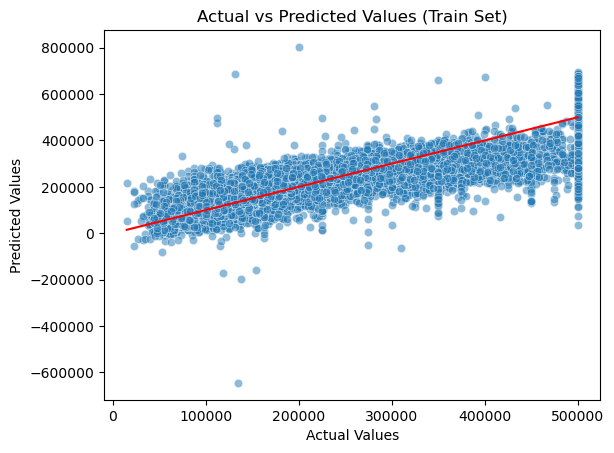

In [83]:
train_predictions = lr.predict(X_train)
sns.scatterplot(x=y_train, y=train_predictions, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red')
plt.title('Actual vs Predicted Values (Train Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

4. From the sklearn metrics module, print the mean_squared_error and R^2-score. What does the metrics tell us?

In [90]:
from sklearn import metrics

In [92]:

from sklearn.metrics import mean_squared_error, r2_score

test_predictions = lr.predict(X_test)
mse = mean_squared_error(y_test, test_predictions)
r2 = r2_score(y_test, test_predictions)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 4550352230.241356
R-squared: 0.6520740923657691


#### Final Predictions

1. Now you are ready to make prediction on the test data. Do that and visualize your results in a new scatterplot.

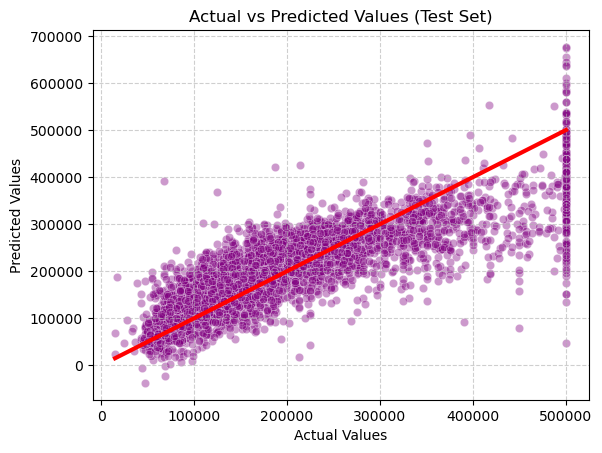

In [93]:
final_test_predictions = lr.predict(X_test)
sns.scatterplot(x=y_test, y=final_test_predictions, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=3)
plt.title('Actual vs Predicted Values (Test Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

2. Print the mean_squared_error and R^2-score again. What has happened?

In [94]:
train_predictions = lr.predict(X_train)
test_predictions = lr.predict(X_test)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)

mse_train = mean_squared_error(y_train, train_predictions)
mse_test = mean_squared_error(y_test, test_predictions)
print(f"Train R-squared: {r2_train}")
print(f"Test R-squared: {r2_test}")
print(f"Train Mean Squared Error: {mse_train}")
print(f"Test Mean Squared Error: {mse_test}")   

Train R-squared: 0.6496043505475808
Test R-squared: 0.6520740923657691
Train Mean Squared Error: 4685072901.573245
Test Mean Squared Error: 4550352230.241356


3. There is another metric called Root mean squared error, Which is the square root of the MSE. Calculate the RMSE.

# Bonus Questions 1

1. Create a dataframe with two columns, one consisting of the y_test and one of your model's predictions.

2. Make a series of of your new dataframe, by calculating the predicted error in absolut numbers. Save this series to variable name `absolute_errors`.

3. If you take the mean of your series, you will get the mean absolute errors, which is another metric for Linear Regressions.

# Bonus Question 2 - Build a Random Forest Regressor

1. Build, fit and train a `RandomForestRegressor` model. Do this by following the same staps that you followed when building your `LinearRegression`.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

2. Make prediction on the test data and evaluate you results.